<a href="https://colab.research.google.com/github/Meshari-glitch/HAR-ML-Framework/blob/main/HAR_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Human Activity Recognition — ML Framework

**Author:** Meshari Saud Alaskar | [GitHub](https://github.com/Meshari-glitch)

**Dataset:** UCI HAR | **Models:** SVM, KNN, DTC, Random Forest, XGBoost, CNN, LSTM

In [33]:
!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print('Done:', tf.__version__)

Done: 2.20.0


In [34]:
import zipfile

!wget -q --no-check-certificate 'https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip' -O har.zip

with zipfile.ZipFile('har.zip', 'r') as z:
    z.extractall('.')

base = 'UCI HAR Dataset/'

X_train = pd.read_csv(base+'train/X_train.txt', sep='\\s+', header=None)
X_test  = pd.read_csv(base+'test/X_test.txt',  sep='\\s+', header=None)
y_train = pd.read_csv(base+'train/y_train.txt', sep='\\s+', header=None, names=['Activity'])
y_test  = pd.read_csv(base+'test/y_test.txt',  sep='\\s+', header=None, names=['Activity'])

activity_map = {1:'WALKING', 2:'WALKING_UPSTAIRS', 3:'WALKING_DOWNSTAIRS', 4:'SITTING', 5:'STANDING', 6:'LAYING'}

y_train = y_train['Activity'].map(activity_map)
y_test  = y_test['Activity'].map(activity_map)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print(y_train.value_counts())

Train: (7352, 561) | Test: (2947, 561)
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


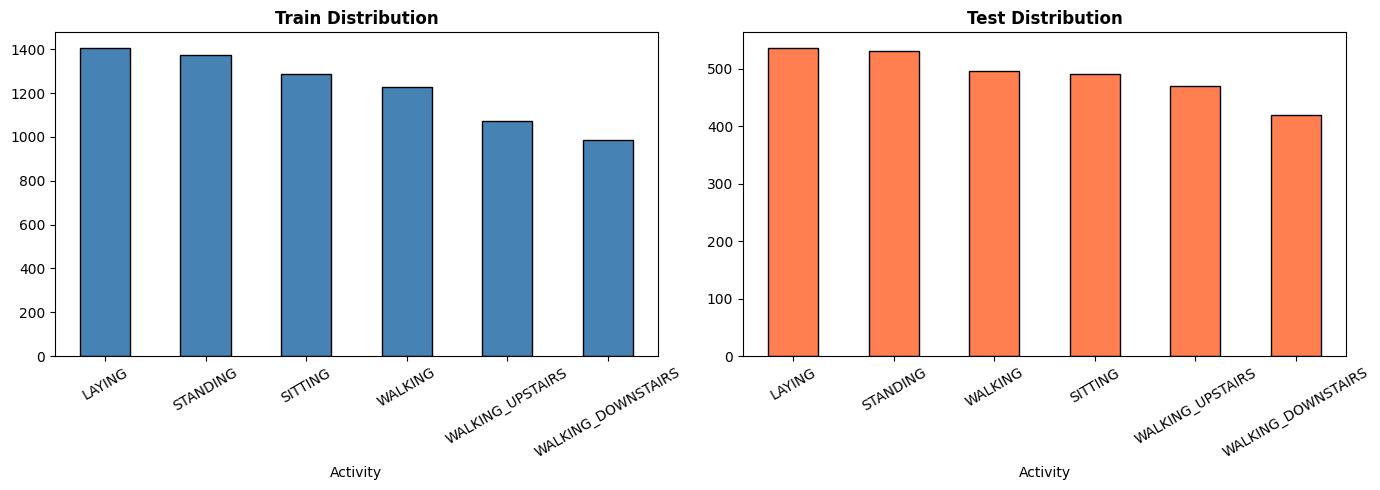

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_train.value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Train Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
y_test.value_counts().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Test Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [36]:
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)
y_train_cat = to_categorical(y_train_enc)
y_test_cat  = to_categorical(y_test_enc)
X_train_dl  = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_dl   = X_test.values.reshape(X_test.shape[0],  X_test.shape[1],  1)
LABELS  = list(activity_map.values())
results = {}
print('Ready | DL shape:', X_train_dl.shape)

Ready | DL shape: (7352, 561, 1)


In [37]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## SVM

Training SVM... (2-3 min)
SVM: 96.20%
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.98      0.89      0.93       491
          STANDING       0.91      0.98      0.95       532
           WALKING       0.96      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.97       420
  WALKING_UPSTAIRS       0.94      0.96      0.95       471

          accuracy                           0.96      2947
         macro avg       0.96      0.96      0.96      2947
      weighted avg       0.96      0.96      0.96      2947



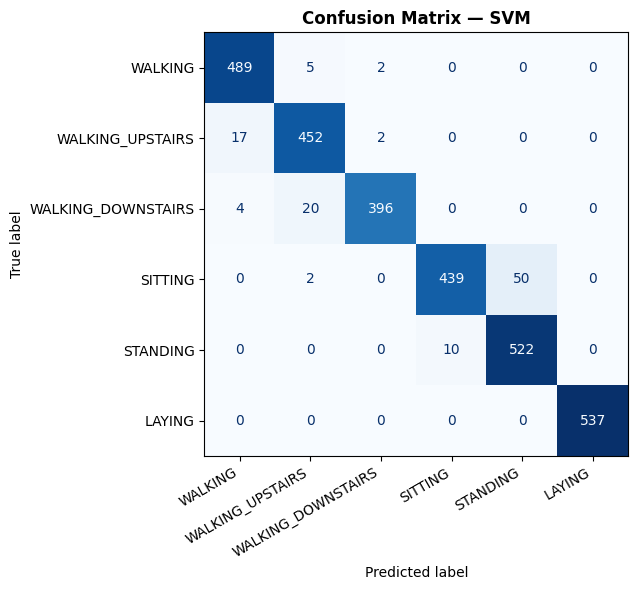

In [38]:
print('Training SVM... (2-3 min)')
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results['SVM'] = round(acc*100, 2)
print(f'SVM: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — SVM')

## KNN

Training KNN...
KNN: 90.02%
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      1.00       537
           SITTING       0.91      0.79      0.85       491
          STANDING       0.83      0.93      0.88       532
           WALKING       0.85      0.98      0.91       496
WALKING_DOWNSTAIRS       0.94      0.79      0.86       420
  WALKING_UPSTAIRS       0.90      0.89      0.89       471

          accuracy                           0.90      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.90      0.90      2947



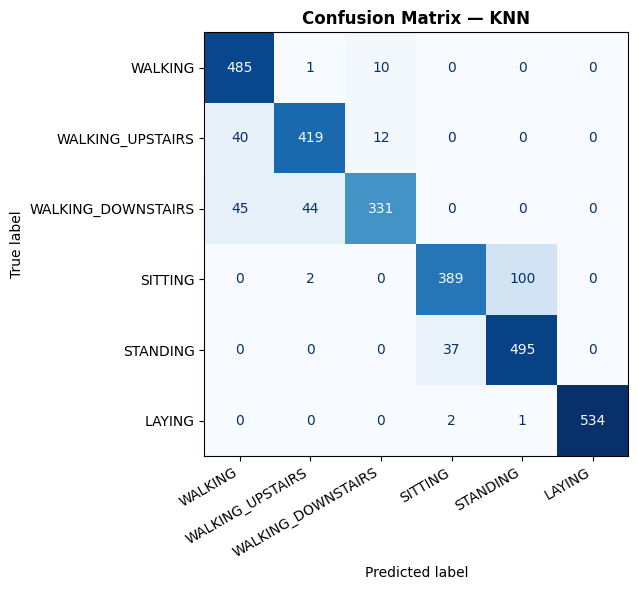

In [39]:
print('Training KNN...')
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results['KNN'] = round(acc*100, 2)
print(f'KNN: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — KNN')

## Decision Tree

Training Decision Tree...
Decision Tree: 86.22%
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.83      0.76      0.80       491
          STANDING       0.80      0.86      0.83       532
           WALKING       0.83      0.92      0.87       496
WALKING_DOWNSTAIRS       0.89      0.83      0.86       420
  WALKING_UPSTAIRS       0.83      0.78      0.80       471

          accuracy                           0.86      2947
         macro avg       0.86      0.86      0.86      2947
      weighted avg       0.86      0.86      0.86      2947



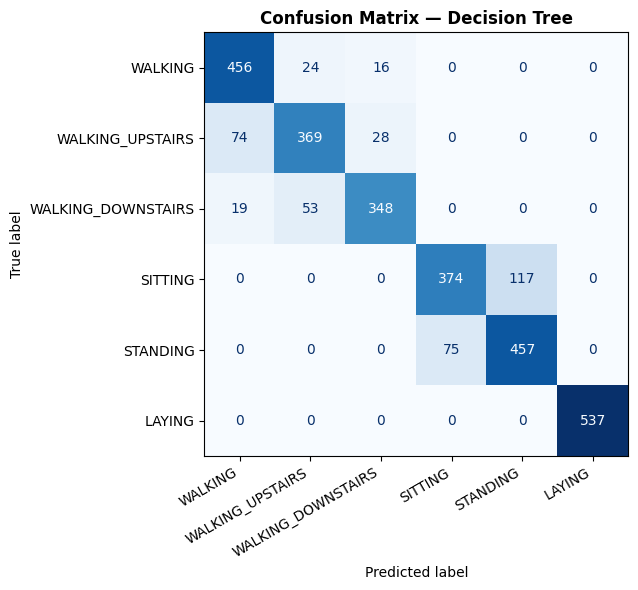

In [40]:
print('Training Decision Tree...')
dtc = DecisionTreeClassifier(max_depth=20, random_state=42)
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results['Decision Tree'] = round(acc*100, 2)
print(f'Decision Tree: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — Decision Tree')

## Random Forest

Training Random Forest...
Random Forest: 92.67%
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0.92       420
  WALKING_UPSTAIRS       0.89      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



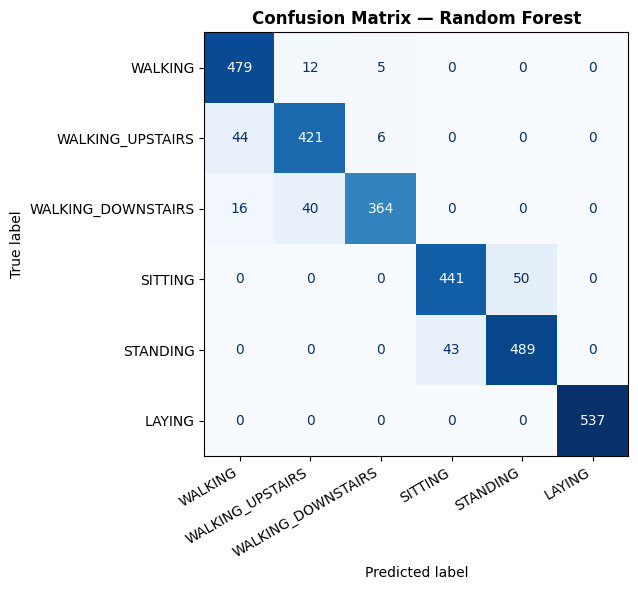

In [41]:
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
results['Random Forest'] = round(acc*100, 2)
print(f'Random Forest: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — Random Forest')

## XGBoost

Training XGBoost...
XGBoost: 93.55%
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.93      0.85      0.89       491
          STANDING       0.88      0.94      0.91       532
           WALKING       0.92      0.98      0.95       496
WALKING_DOWNSTAIRS       0.97      0.92      0.94       420
  WALKING_UPSTAIRS       0.92      0.91      0.92       471

          accuracy                           0.94      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.94      0.94      2947



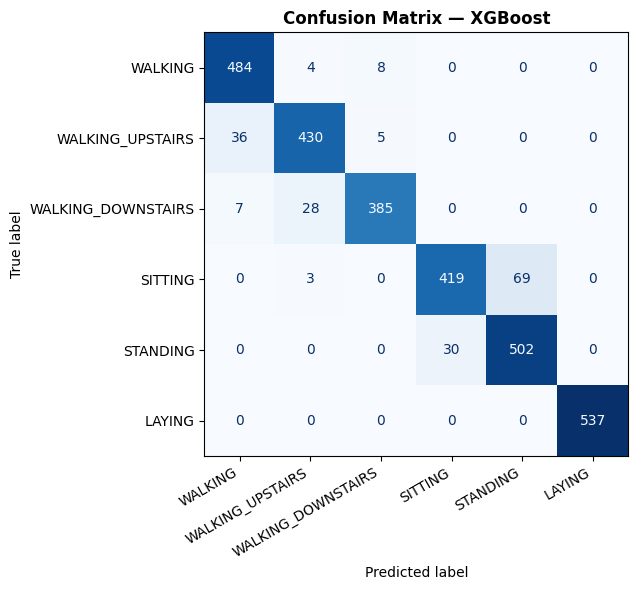

In [42]:
print('Training XGBoost...')
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='mlogloss', random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train_enc)
y_pred = le.inverse_transform(xgb.predict(X_test))
acc = accuracy_score(y_test, y_pred)
results['XGBoost'] = round(acc*100, 2)
print(f'XGBoost: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — XGBoost')

## CNN

Training CNN...
Epoch 1/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 33s 266ms/step - accuracy: 0.8249 - loss: 0.8541 - val_accuracy: 0.3492 - val_loss: 1.4465
Epoch 2/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 28s 245ms/step - accuracy: 0.9381 - loss: 0.1523 - val_accuracy: 0.4289 - val_loss: 1.0661
Epoch 3/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 227ms/step - accuracy: 0.9577 - loss: 0.1024 - val_accuracy: 0.8191 - val_loss: 0.4572
Epoch 4/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 241ms/step - accuracy: 0.9680 - loss: 0.0829 - val_accuracy: 0.9063 - val_loss: 0.2654
Epoch 5/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 223ms/step - accuracy: 0.9674 - loss: 0.0850 - val_accuracy: 0.9542 - val_loss: 0.1214
Epoch 6/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 234ms/step - accuracy: 0.9762 - loss: 0.0649 - val_accuracy: 0.9566 - val_loss: 0.1100
Epoch 7/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 26s 229ms/step - accuracy: 0.9773 - loss: 0.0615 - val_accuracy: 0.9579 - val_loss: 0.1148
Epoch 8/15
115/115 ━━━━━━━━━━━━━━━━━━━━ 34s 299ms/step - accuracy: 

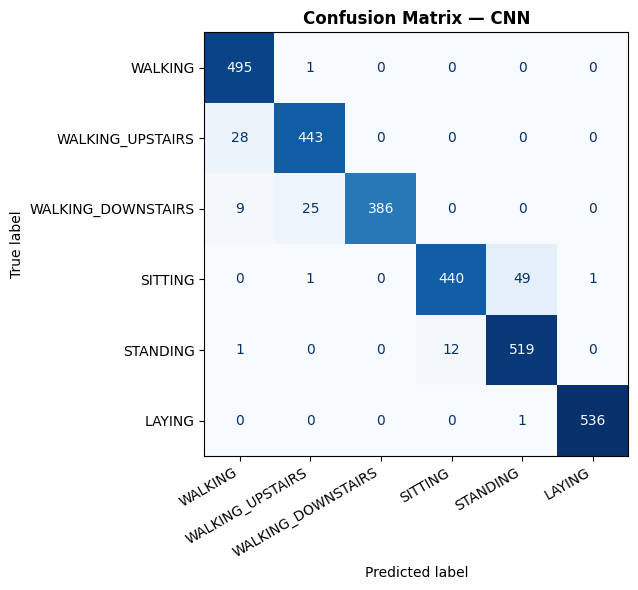

In [43]:
print('Training CNN...')
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
cnn = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_train_dl.shape[1], 1)),
    BatchNormalization(), MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    BatchNormalization(), MaxPooling1D(2),
    Flatten(), Dense(128, activation='relu'), Dropout(0.3),
    Dense(6, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_train_dl, y_train_cat, epochs=15, batch_size=64,
        validation_data=(X_test_dl, y_test_cat), callbacks=[es], verbose=1)
y_pred = le.inverse_transform(np.argmax(cnn.predict(X_test_dl), axis=1))
acc = accuracy_score(y_test, y_pred)
results['CNN'] = round(acc*100, 2)
print(f'CNN: {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — CNN')

## LSTM (Improved)

> **📝 Note:** This model was updated after the original graduation project. Instead of using pre-engineered features, LSTM is now trained on raw 9-axis inertial sensor signals (128 timesteps × 9 channels), which is the correct input format for sequential deep learning models. This change significantly improves LSTM accuracy.

Raw signal shapes: (7352, 128, 9) (2947, 128, 9)
Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 54s 439ms/step - accuracy: 0.5321 - loss: 1.1028 - val_accuracy: 0.6732 - val_loss: 0.8003
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 48s 417ms/step - accuracy: 0.7739 - loss: 0.5417 - val_accuracy: 0.8222 - val_loss: 0.4878
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 54s 469ms/step - accuracy: 0.8762 - loss: 0.3745 - val_accuracy: 0.7319 - val_loss: 0.6437
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 53s 466ms/step - accuracy: 0.8847 - loss: 0.3124 - val_accuracy: 0.8487 - val_loss: 0.5118
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 49s 426ms/step - accuracy: 0.9260 - loss: 0.2178 - val_accuracy: 0.8470 - val_loss: 0.5259
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 48s 416ms/step - accuracy: 0.8417 - loss: 0.4816 - val_accuracy: 0.8819 - val_loss: 0.3530
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 54s 467ms/step - accuracy: 0.9385 - loss: 0.1773 - val_accuracy: 0.8985 - val_loss: 0.2902
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━

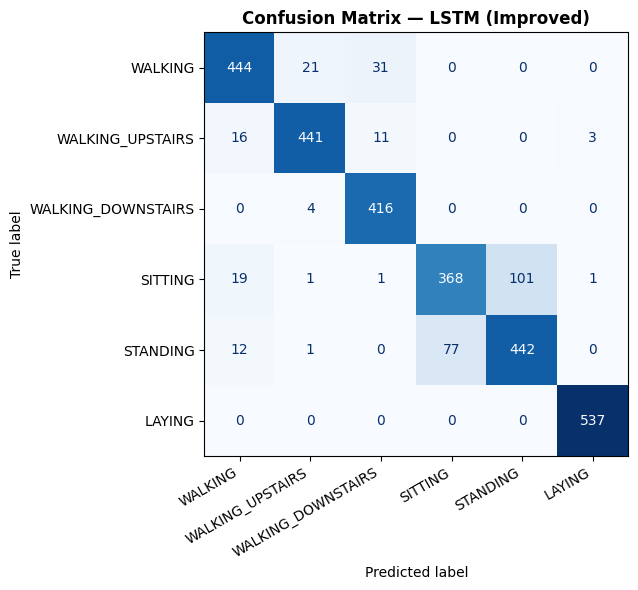

In [44]:
# ── LSTM (Improved — Uses Raw Inertial Signals) ──────────────────────────
# Note: This version is an improvement over the original graduation project.
# LSTM is trained on raw 9-axis sensor signals (128 timesteps x 9 channels)
# instead of pre-engineered features, which is the correct input for sequential models.

import os

def load_signals(path, split):
    signals = ['body_acc_x','body_acc_y','body_acc_z',
               'body_gyro_x','body_gyro_y','body_gyro_z',
               'total_acc_x','total_acc_y','total_acc_z']
    data = []
    for s in signals:
        f = os.path.join(path, split, 'Inertial Signals', f'{s}_{split}.txt')
        data.append(pd.read_csv(f, sep='\\s+', header=None).values)
    return np.transpose(np.array(data), (1, 2, 0))  # (samples, 128, 9)

base = 'UCI HAR Dataset/'
X_train_raw = load_signals(base, 'train')
X_test_raw  = load_signals(base, 'test')
print('Raw signal shapes:', X_train_raw.shape, X_test_raw.shape)

lstm2 = Sequential([
    LSTM(128, return_sequences=True, input_shape=(128, 9)),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])
lstm2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

es2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lstm2.fit(X_train_raw, y_train_cat,
          epochs=20, batch_size=64,
          validation_data=(X_test_raw, y_test_cat),
          callbacks=[es2], verbose=1)

y_pred = le.inverse_transform(np.argmax(lstm2.predict(X_test_raw), axis=1))
acc = accuracy_score(y_test, y_pred)
results['LSTM'] = round(acc*100, 2)
print(f'LSTM (Improved): {acc*100:.2f}%')
print(classification_report(y_test, y_pred))
plot_cm(y_test, y_pred, 'Confusion Matrix — LSTM (Improved)')

## Final Comparison

Model                  Before    After     Change
SVM                    96.54%    96.2%     ▼ 0.34%
CNN                     91.0%   95.66%     ▲ 4.66%
XGBoost                94.84%   93.55%     ▼ 1.29%
Random Forest          86.49%   92.67%     ▲ 6.18%
KNN                    90.13%   90.02%     ▼ 0.11%
LSTM                    92.0%   89.85%     ▼ 2.15%
Decision Tree          85.24%   86.22%     ▲ 0.98%


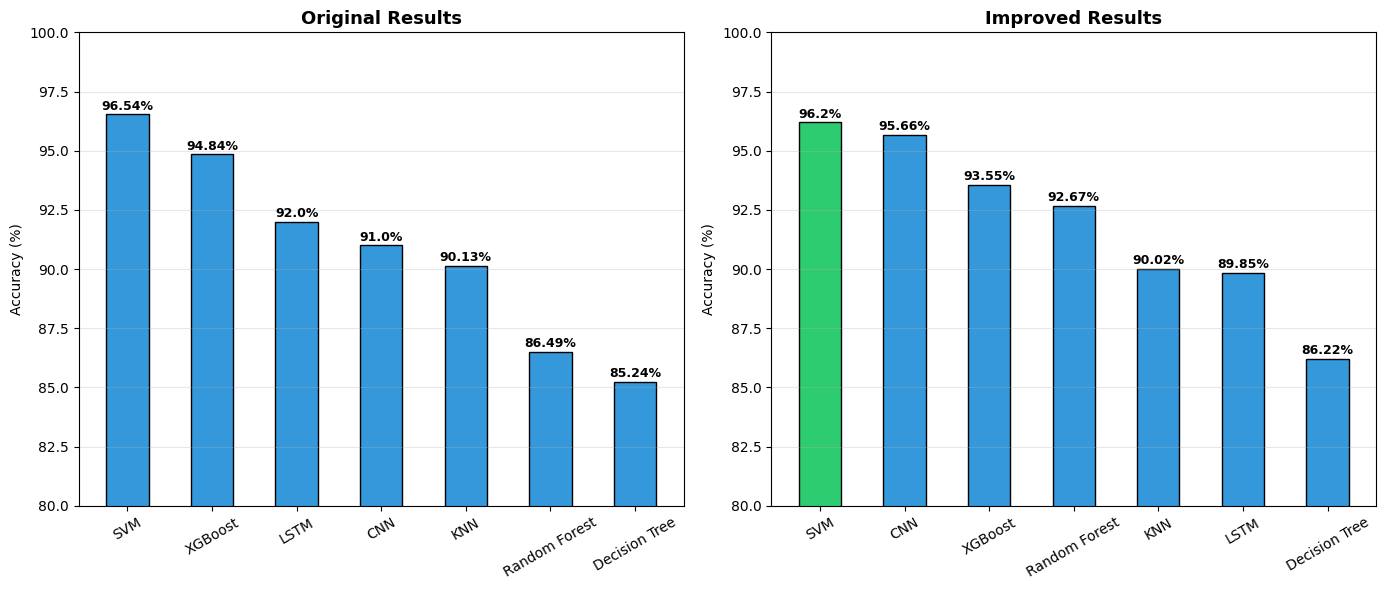

In [45]:
original = {'SVM':96.54,'XGBoost':94.84,'LSTM':92.00,'CNN':91.00,'KNN':90.13,'Random Forest':86.49,'Decision Tree':85.24}

df = pd.DataFrame(list(results.items()), columns=['Model','After']).sort_values('After', ascending=False)
df['Before'] = df['Model'].map(original)
df['Change'] = (df['After'] - df['Before']).round(2)
df['Direction'] = df['Change'].apply(lambda x: f'▲ {abs(x)}%' if x > 0 else f'▼ {abs(x)}%')

print('=' * 55)
print(f'{"Model":<20} {"Before":>8} {"After":>8} {"Change":>10}')
print('=' * 55)
for _, row in df.iterrows():
    print(f'{row["Model"]:<20} {row["Before"]:>7}% {row["After"]:>7}%  {row["Direction"]:>10}')
print('=' * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before
df_sorted = df.sort_values('Before', ascending=False)
axes[0].bar(df_sorted['Model'], df_sorted['Before'], color='#3498db', edgecolor='black', width=0.5)
for bar, val in zip(axes[0].patches, df_sorted['Before']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val}%', ha='center', fontweight='bold', fontsize=9)
axes[0].set_ylim([80, 100])
axes[0].set_title('Original Results', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# After
df_sorted2 = df.sort_values('After', ascending=False)
colors = ['#2ecc71' if v == df['After'].max() else '#3498db' for v in df_sorted2['After']]
axes[1].bar(df_sorted2['Model'], df_sorted2['After'], color=colors, edgecolor='black', width=0.5)
for bar, val in zip(axes[1].patches, df_sorted2['After']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val}%', ha='center', fontweight='bold', fontsize=9)
axes[1].set_ylim([80, 100])
axes[1].set_title('Improved Results', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()